In [1]:
! pip install kagglehub wandb

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import math

import torch
import torch.nn as nn
from torch.nn import init
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.impute
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, random_split
import kagglehub
import os
import wandb
import torch.optim as optim

Before running the following code, please make sure you've installed the packages mentioned above.

# Triformer Structure
Here we define the structure of the Triformer, along with the comments helping understand the structure and connecting to the paper.

In [53]:
class Triformer(nn.Module):
    def __init__(self, device, num_nodes, input_dim, output_dim, channels, dynamic, lag,
                 horizon, patch_sizes, supports, mem_dim):
        super(Triformer, self).__init__()
        self.factorized = True
        print('Predicting {} steps ahead'.format(horizon))
        self.num_nodes = num_nodes
        self.output_dim = output_dim # output dimension
        self.channels = channels
        self.dynamic = dynamic
        self.start_fc = nn.Linear(in_features=input_dim, out_features=self.channels) # embedding
        self.layers = nn.ModuleList()
        self.skip_generators = nn.ModuleList()
        self.horizon = horizon # length of predicted window
        self.supports = supports 
        self.lag = lag #length of input sequence

        cuts = lag
        for patch_size in patch_sizes:
            if cuts % patch_size != 0:
                raise Exception('Lag not divisible by patch size')

            cuts = int(cuts / patch_size)
            self.layers.append(Layer(device=device, input_dim=channels,
                                     dynamic=dynamic, num_nodes=num_nodes, cuts=cuts,
                                     cut_size=patch_size, factorized=self.factorized))
            # Generate weights and biases for skip connections
            self.skip_generators.append(WeightGenerator(in_dim=cuts * channels, out_dim=256, number_of_weights=1,
                                                        mem_dim=mem_dim, num_nodes=num_nodes, factorized=False))

        self.custom_linear = CustomLinear(factorized=False)
        self.projections = nn.Sequential(*[
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, horizon)])
        self.notprinted = True

    def forward(self, batch_x, batch_x_mark, dec_inp, batch_y_mark):
        # Only prints out the first input dimension
        if self.notprinted:
            self.notprinted = False
            print(batch_x.shape)
        # Initial embedding
        x = self.start_fc(batch_x)
        batch_size = x.size(0)
        skip = 0

        for layer, skip_generator in zip(self.layers, self.skip_generators):
            x = layer(x)
            weights, biases = skip_generator()
            # reshape gives [32, 1, 1, 48 * 16], aggregating info from patches
            skip_inp = x.transpose(2, 1).reshape(batch_size, 1, self.num_nodes, -1)
            # Add skip connection to the original input
            skip = skip + self.custom_linear(skip_inp, weights[-1], biases[-1])

        x = torch.relu(skip).squeeze(1)
        # Output dim [32, 7, 1]
        return self.projections(x).transpose(2, 1)


class Layer(nn.Module):
    def __init__(self, device, input_dim, num_nodes, cuts, cut_size, dynamic, factorized):
        super(Layer, self).__init__()
        self.device = device
        self.input_dim = input_dim
        self.num_nodes = num_nodes
        self.dynamic = dynamic
        self.cuts = cuts
        self.cut_size = cut_size
        # Analogous to positional embedding
        self.temporal_embeddings = nn.Parameter(torch.rand(cuts, 1, 1, self.num_nodes, 5).to(device),
                                                requires_grad=True).to(device)

        self.embeddings_generator = nn.ModuleList([nn.Sequential(*[
            nn.Linear(5, input_dim)]) for _ in range(cuts)])
        # Equation (4) function g
        self.out_net1 = nn.Sequential(*[
            nn.Linear(input_dim, input_dim ** 2),
            nn.Tanh(),
            nn.Linear(input_dim ** 2, input_dim),
            nn.Tanh(),
        ])
        # Equation (4) function sigma
        self.out_net2 = nn.Sequential(*[
            nn.Linear(input_dim, input_dim ** 2),
            nn.Tanh(),
            nn.Linear(input_dim ** 2, input_dim),
            nn.Sigmoid(),
        ])

        self.temporal_att = TemporalAttention(input_dim, factorized=factorized)
        self.weights_generator_distinct = WeightGenerator(input_dim, input_dim, mem_dim=5, num_nodes=num_nodes,
                                                          factorized=factorized, number_of_weights=2)
        self.weights_generator_shared = WeightGenerator(input_dim, input_dim, mem_dim=None, num_nodes=num_nodes,
                                                        factorized=False, number_of_weights=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x shape: B T N C
        batch_size = x.size(0)

        data_concat = None
        out = 0

        weights_shared, biases_shared = self.weights_generator_shared()
        weights_distinct, biases_distinct = self.weights_generator_distinct()

        for i in range(self.cuts):
            # shape is (B, cut_size, N, C)
            t = x[:, i * self.cut_size:(i + 1) * self.cut_size, :, :]

            if i != 0:
                # Gating in equation (4)
                out = self.out_net1(out) * self.out_net2(out)
            # [48, 1, 1, 1, 5] -> [32, 48, 2, 1, 16] using first patch size and batch size 32 as an example
            # Add positional information of current state to the previous patches (only for 1 patch)
            emb = self.embeddings_generator[i](self.temporal_embeddings[i]).repeat(batch_size, 1, 1, 1) + out
            t = torch.cat([emb, t], dim=1)
            # Define tmporal attention layer
            out = self.temporal_att(t[:, :1, :, :], t, t, weights_distinct, biases_distinct, weights_shared,
                                    biases_shared)

            if data_concat == None:
                data_concat = out
            else:
                data_concat = torch.cat([data_concat, out], dim=1)

        return self.dropout(data_concat)


class CustomLinear(nn.Module):
    def __init__(self, factorized):
        super(CustomLinear, self).__init__()
        self.factorized = factorized

    def forward(self, input, weights, biases):
        if self.factorized:
            return torch.matmul(input.unsqueeze(3), weights).squeeze(3) + biases
        else:
            return torch.matmul(input, weights) + biases


class TemporalAttention(nn.Module):
    def __init__(self, in_dim, factorized):
        super(TemporalAttention, self).__init__()
        self.K = 2
        # Multihead
        if in_dim % self.K != 0:
            raise Exception('Hidden size is not divisible by the number of attention heads')

        self.head_size = int(in_dim // self.K)
        self.custom_linear = CustomLinear(factorized)

    def forward(self, query, key, value, weights_distinct, biases_distinct, weights_shared, biases_shared):
        batch_size = query.shape[0]

        # [batch_size, num_step, N, K * head_size]
        # We need to transform "key" and "value", so we need to number_of_weights = 2
        key = self.custom_linear(key, weights_distinct[0], biases_distinct[0])
        value = self.custom_linear(value, weights_distinct[1], biases_distinct[1])

        # [K * batch_size, num_step, N, head_size]
        query = torch.cat(torch.split(query, self.head_size, dim=-1), dim=0)
        key = torch.cat(torch.split(key, self.head_size, dim=-1), dim=0)
        value = torch.cat(torch.split(value, self.head_size, dim=-1), dim=0)

        # query: [K * batch_size, N, 1, head_size]
        # key:   [K * batch_size, N, head_size, num_step]
        # value: [K * batch_size, N, num_step, head_size]
        query = query.permute((0, 2, 1, 3))
        key = key.permute((0, 2, 3, 1))
        value = value.permute((0, 2, 1, 3))

        attention = torch.matmul(query, key)  # [K * batch_size, N, num_step, num_step]
        attention /= (self.head_size ** 0.5)

        # normalize the attention scores
        attention = torch.softmax(attention, dim=-1)

        x = torch.matmul(attention, value)  # [batch_size * head_size, num_step, N, K]
        x = x.permute((0, 2, 1, 3))
        x = torch.cat(torch.split(x, batch_size, dim=0), dim=-1)

        # projection
        x = self.custom_linear(x, weights_shared[0], biases_shared[0])
        x = torch.tanh(x)
        x = self.custom_linear(x, weights_shared[1], biases_shared[1])
        return x


class WeightGenerator(nn.Module):
    def __init__(self, in_dim, out_dim, mem_dim, num_nodes, factorized, number_of_weights=4):
        super(WeightGenerator, self).__init__()
        # number_of_weights here is the attention weight, not N, i.e. the number of variables
        self.number_of_weights = number_of_weights
        self.mem_dim = mem_dim
        self.num_nodes = num_nodes
        self.factorized = factorized
        self.out_dim = out_dim
        if self.factorized:
            # self.memory = nn.Parameter(torch.randn(num_nodes, mem_dim), requires_grad=True).to('cuda:0')
            self.memory = nn.Parameter(torch.randn(num_nodes, mem_dim), requires_grad=True).to('cpu')
            self.generator = self.generator = nn.Sequential(*[
                nn.Linear(mem_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 64),
                nn.Tanh(),
                nn.Linear(64, 5 * 5)
            ])
            # d * a, matrix L in Section 4.3 Figure 4 (b)
            self.P = nn.ParameterList(
                [nn.Parameter(torch.Tensor(in_dim, self.mem_dim), requires_grad=True) for _ in
                 range(number_of_weights)])
            # a * d, matrix R in section 4.3 Figure 4 (b)
            self.Q = nn.ParameterList(
                [nn.Parameter(torch.Tensor(self.mem_dim, out_dim), requires_grad=True) for _ in
                 range(number_of_weights)])
            # a * a * N, a << d to be light-weighted
            self.B = nn.ParameterList(
                [nn.Parameter(torch.Tensor(self.mem_dim ** 2, out_dim), requires_grad=True) for _ in
                 range(number_of_weights)])
        else:
            # Dense matrix for weights and biases
            self.P = nn.ParameterList(
                [nn.Parameter(torch.Tensor(in_dim, out_dim), requires_grad=True) for _ in range(number_of_weights)])
            self.B = nn.ParameterList(
                [nn.Parameter(torch.Tensor(1, out_dim), requires_grad=True) for _ in range(number_of_weights)])
        # Reset parameters after structuring
        self.reset_parameters()

    def reset_parameters(self):
        list_params = [self.P, self.Q, self.B] if self.factorized else [self.P]
        for weight_list in list_params:
            for weight in weight_list:
                init.kaiming_uniform_(weight, a=math.sqrt(5))

        if not self.factorized:
            for i in range(self.number_of_weights):
                fan_in, _ = init._calculate_fan_in_and_fan_out(self.P[i])
                bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
                init.uniform_(self.B[i], -bound, bound)

    def forward(self):
        # Section 4.3 Figure 4
        if self.factorized:
            # If we change the mem_dim, we also adjust the dimensions in self.generator
            memory = self.generator(self.memory.unsqueeze(1))
            bias = [torch.matmul(memory, self.B[i]).squeeze(1) for i in range(self.number_of_weights)]
            memory = memory.view(self.num_nodes, self.mem_dim, self.mem_dim)
            weights = [torch.matmul(torch.matmul(self.P[i], memory), self.Q[i]) for i in range(self.number_of_weights)]
            return weights, bias
        else:
            return self.P, self.B

In this section, we define the data processing pipeline, and training-testing procedure, including plotting function for results demonstration. Please refer to the report for details.

In [57]:
# Define the Dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, dataframe, target, covariates, seq_len, horizon, num_nodes):
        # dataframe["date"] = pd.to_datetime(dataframe["date"])
        dataframe = dataframe.sort_values(by="date")
        dataframe = dataframe.drop(columns=["date"])
        
        imputer = sklearn.impute.SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(dataframe)
        std = StandardScaler().fit_transform(imputer)
        dataframe = pd.DataFrame(std, index=dataframe.index, columns=dataframe.columns)
        # Create input-output pairs
        inputs = []
        svm = np.lib.stride_tricks.sliding_window_view
        for covariate in covariates:
            input_seq = svm(dataframe[covariate][:-horizon], seq_len)
            inputs.append(input_seq)
        targets = svm(dataframe[target][seq_len:], horizon)

        # Convert to numpy arrays
        inputs = np.transpose(np.array(inputs)[:, :, np.newaxis, :], (1, 3, 2, 0))
        targets = np.array(targets)[:, :, np.newaxis]  # Shape: (num_samples, horizon, 1)

        # Convert to tensors
        self.inputs = torch.tensor(inputs, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

        self.seq_len = seq_len
        self.horizon = horizon
        self.num_nodes = num_nodes
        
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        x = self.inputs[index]  # All covariates
        y = self.targets[index]  # Target variable
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Define the model (assuming TriFormer class exists)
def train_and_test_model(
    dataframe,
    target,
    covariates,
    seq_len=96,
    horizon=7,
    batch_size=32,
    epochs=10,
    learning_rate=0.001,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    channels=16,
    patch_sizes=[2, 4],
    lag=None,
    dynamic=True,
    mem_dim=8,
    output_dim=1,
    num_nodes=1
):
    """
    Trains and tests the TriFormer model using a given dataframe.
    
    Args:
        dataframe (pd.DataFrame): Input data containing time series.
        target (str): Response variable name.
        covariates (list): List of predictor variable names.
        seq_len (int): Sequence length for the input data.
        horizon (int): Prediction horizon.
        batch_size (int): Batch size for training.
        epochs (int): Number of training epochs.
        learning_rate (float): Learning rate for optimizer.
        device (torch.device): Device to train the model on.
        channels (int): Number of channels in the model.
        patch_sizes (list): List of patch sizes for the model.
        lag (int): Lag value, defaults to seq_len.
        dynamic (bool): Whether to use dynamic weights.
        mem_dim (int): Memory dimension for weight generation.
        output_dim (int): Number of outputs (targets).

    Returns:
        Trained model and test loss.
    """
    # Default lag to seq_len if not provided
    if lag is None:
        lag = seq_len

    # Split the dataset
    train_size = int(0.7 * len(dataframe))
    val_size = int(0.15 * len(dataframe))
    test_size = len(dataframe) - train_size - val_size

    train_df = dataframe.iloc[:train_size]
    val_df = dataframe.iloc[train_size:train_size + val_size]
    test_df = dataframe.iloc[train_size + val_size:]

    # Prepare datasets and dataloaders
    train_dataset = TimeSeriesDataset(train_df, target, covariates, seq_len, horizon,num_nodes)
    val_dataset = TimeSeriesDataset(val_df, target, covariates, seq_len, horizon, num_nodes)
    test_dataset = TimeSeriesDataset(test_df, target, covariates, seq_len, horizon, num_nodes)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize the model
    model = Triformer(
        device=device,
        num_nodes=1,  # Number of covariates
        input_dim=len(covariates),  # Dimension of input features
        output_dim=output_dim,
        channels=channels,
        dynamic=dynamic,
        lag=lag,
        horizon=horizon,
        patch_sizes=patch_sizes,
        supports=None,
        mem_dim=mem_dim,
    ).to(device)

    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    def train_model():
        model.train()
        for epoch in range(epochs):
            epoch_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)

                # Forward pass
                optimizer.zero_grad()
                predictions = model(batch_x, None, None, None)

                # Compute loss
                loss = criterion(predictions, batch_y)
                epoch_loss += loss.item()

                # Backward pass
                loss.backward()
                optimizer.step()

            print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {epoch_loss / len(train_loader):.4f}")

    # Testing loop
    def test_model():
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                predictions = model(batch_x, None, None, None)
                loss = criterion(predictions, batch_y)
                total_loss += loss.item()
        print(f"Test Loss: {total_loss / len(test_loader):.4f}")
        return total_loss / len(test_loader)

    # Train and test
    train_model()
    test_loss = test_model()
    
    def plot_predictions(model, test_loader):
        model.eval()
        batch_x, batch_y = next(iter(test_loader))
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x, None, None, None)
        # print(predictions.shape)

        plt.figure(figsize=(10, 5))
        for i in range(min(5, batch_x.size(0))):  # Plot for 5 samples
            plt.subplot(1, 5, i + 1)
            plt.plot(range(batch_y.size(1)), batch_y[i, :, 0].cpu().numpy(), label="True")
            plt.plot(range(predictions.size(1)), predictions[i, :, 0].cpu().detach().numpy(), label="Predicted")
            plt.title(f"Sample {i+1}")
            plt.legend()
        plt.tight_layout()
        plt.show()

    # Plot predictions
    plot_predictions(model, test_loader)
    
    return model, test_loss

Here we define functions for saving and loading checkpoints, in case the training is halted halfway through.

In [7]:
def save_checkpoint(model, optimizer, epoch, filepath):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
    }
    torch.save(checkpoint, filepath)
    print(f"Checkpoint saved at {filepath}")

def load_checkpoint(filepath, model, optimizer):
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Checkpoint loaded. Resuming from epoch {start_epoch}.")
    return start_epoch



# ETTm1 96_7_6
Here we are testing on the ETTm1 dataset, with sequence length 96, horizon 7 and input dimension 6, which is abbreviated as 96_7_6 (all the following titles are formated similarly). Please change the file path for the experiments below, as they use different datasets.

In [13]:
# Read in data
path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv"

# Other paths include: 
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv,
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv, 
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv, 
# "https://drive.google.com/uc?export=download&id=1rUPdR7R2iWFW-LMoDdHoO2g4KgnkpFzP",
# "https://drive.google.com/uc?export=download&id=1UBRz-aM_57i_KCC-iaSWoKDPTGGv6EaG"

df = pd.read_csv(path)

In [8]:
# Specify the target variable and covariates
target_column = "OT"
covariates = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]
torch.set_num_threads(8)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=96,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 4, 12],
    dynamic=True,
    num_nodes=1
)


Predicting 7 steps ahead
torch.Size([64, 96, 1, 6])


/tmp/ipykernel_1589266/3845621654.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.4974
Epoch 2/10, Training Loss: 0.3275
Epoch 3/10, Training Loss: 0.2565
Epoch 4/10, Training Loss: 0.2119
Epoch 5/10, Training Loss: 0.1890
Epoch 6/10, Training Loss: 0.1781
Epoch 7/10, Training Loss: 0.1681
Epoch 8/10, Training Loss: 0.1579
Epoch 9/10, Training Loss: 0.1525
Epoch 10/10, Training Loss: 0.1480
Test Loss: 1.1206


# ETTm1 30_7_6

In [15]:
# Specify the target variable and covariates
target_column = "OT"
covariates = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]
torch.set_num_threads(8)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=30,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 3, 5],
    dynamic=True,
    num_nodes=1
)

Predicting 7 steps ahead
torch.Size([64, 30, 1, 6])


/tmp/ipykernel_1589266/3845621654.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.6540
Epoch 2/10, Training Loss: 0.5697
Epoch 3/10, Training Loss: 0.5473
Epoch 4/10, Training Loss: 0.5279
Epoch 5/10, Training Loss: 0.5153
Epoch 6/10, Training Loss: 0.4978
Epoch 7/10, Training Loss: 0.4793
Epoch 8/10, Training Loss: 0.4619
Epoch 9/10, Training Loss: 0.4471
Epoch 10/10, Training Loss: 0.4295
Test Loss: 1.5163


# ETTh1 96_7_6
WE have finished testing on ETTm1 dataset, and starting from here, we switched to ETTh1 dataset.

In [16]:
# Read in data
path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

# Other paths include: 
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv,
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv, 
# https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv, 
# "https://drive.google.com/uc?export=download&id=1rUPdR7R2iWFW-LMoDdHoO2g4KgnkpFzP",
# "https://drive.google.com/uc?export=download&id=1UBRz-aM_57i_KCC-iaSWoKDPTGGv6EaG"

df = pd.read_csv(path)

In [11]:
# Specify the target variable and covariates
target_column = "OT"
covariates = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]
torch.set_num_threads(7)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=96,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 4, 12],
    dynamic=True,
    num_nodes=1
)


Predicting 7 steps ahead
torch.Size([64, 96, 1, 6])


/tmp/ipykernel_1589266/3845621654.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.6685
Epoch 2/10, Training Loss: 0.4271
Epoch 3/10, Training Loss: 0.3750
Epoch 4/10, Training Loss: 0.2990
Epoch 5/10, Training Loss: 0.2515
Epoch 6/10, Training Loss: 0.2239
Epoch 7/10, Training Loss: 0.2051
Epoch 8/10, Training Loss: 0.1927
Epoch 9/10, Training Loss: 0.1847
Epoch 10/10, Training Loss: 0.1824
Test Loss: 1.2573


# ETTh1 30_7_6

In [21]:
# Specify the target variable and covariates
target_column = "OT"
covariates = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]
torch.set_num_threads(7)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=30,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 3, 5],
    dynamic=True,
    num_nodes=1
)


Predicting 7 steps ahead
torch.Size([64, 30, 1, 6])


/tmp/ipykernel_1589266/3845621654.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.6763
Epoch 2/10, Training Loss: 0.5172
Epoch 3/10, Training Loss: 0.4497
Epoch 4/10, Training Loss: 0.4019
Epoch 5/10, Training Loss: 0.3746
Epoch 6/10, Training Loss: 0.3527
Epoch 7/10, Training Loss: 0.3353
Epoch 8/10, Training Loss: 0.3168
Epoch 9/10, Training Loss: 0.3104
Epoch 10/10, Training Loss: 0.2973
Test Loss: 1.1798


# Gold 96_7_2
Now we start to test on external datasets, using stock market data.

In [22]:
# Download latest version
path = kagglehub.dataset_download("saketk511/2019-2024-us-stock-market-data")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, "Stock Market Dataset.csv"), )

100%|██████████| 155k/155k [00:00<00:00, 7.39MB/s]

Extracting files...
Path to dataset files: /home/yhongda/.cache/kagglehub/datasets/saketk511/2019-2024-us-stock-market-data/versions/1


We rewrite the data processing function as the external data has slightly different formatting. Please run the following command before training using the external dataset.

In [59]:
# Define the Dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, dataframe, target, covariates, seq_len, horizon, num_nodes):
        # dataframe["date"] = pd.to_datetime(dataframe["date"])
        dataframe = dataframe.sort_values(by="Date")
        dataframe = dataframe.drop(columns=["Date"])
        dataframe[target] = pd.to_numeric(dataframe[target].str.replace(',', ''), errors='coerce')
        dataframe[covariates] = dataframe[covariates].apply(pd.to_numeric, errors='coerce', axis=1)
        dataframe = dataframe[covariates] if target in covariates else dataframe[covariates.append(target)]
        
        imputer = sklearn.impute.SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(dataframe)
        std = StandardScaler().fit_transform(imputer)
        dataframe = pd.DataFrame(std, index=dataframe.index, columns=dataframe.columns)
        # Create input-output pairs
        inputs = []
        svm = np.lib.stride_tricks.sliding_window_view
        for covariate in covariates:
            input_seq = svm(dataframe[covariate][:-horizon], seq_len)
            inputs.append(input_seq)
        targets = svm(dataframe[target][seq_len:], horizon)

        # Convert to numpy arrays
        inputs = np.transpose(np.array(inputs)[:, :, np.newaxis, :], (1, 3, 2, 0))
        targets = np.array(targets)[:, :, np.newaxis]  # Shape: (num_samples, horizon, 1)

        # Convert to tensors
        self.inputs = torch.tensor(inputs, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

        self.seq_len = seq_len
        self.horizon = horizon
        self.num_nodes = num_nodes
        
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        x = self.inputs[index]  # All covariates
        y = self.targets[index]  # Target variable
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Define the model (assuming TriFormer class exists)
def train_and_test_model(
    dataframe,
    target,
    covariates,
    seq_len=96,
    horizon=7,
    batch_size=32,
    epochs=10,
    learning_rate=0.001,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    channels=16,
    patch_sizes=[2, 4],
    lag=None,
    dynamic=True,
    mem_dim=8,
    output_dim=1,
    num_nodes=1
):
    """
    Trains and tests the TriFormer model using a given dataframe.
    
    Args:
        dataframe (pd.DataFrame): Input data containing time series.
        target (str): Response variable name.
        covariates (list): List of predictor variable names.
        seq_len (int): Sequence length for the input data.
        horizon (int): Prediction horizon.
        batch_size (int): Batch size for training.
        epochs (int): Number of training epochs.
        learning_rate (float): Learning rate for optimizer.
        device (torch.device): Device to train the model on.
        channels (int): Number of channels in the model.
        patch_sizes (list): List of patch sizes for the model.
        lag (int): Lag value, defaults to seq_len.
        dynamic (bool): Whether to use dynamic weights.
        mem_dim (int): Memory dimension for weight generation.
        output_dim (int): Number of outputs (targets).

    Returns:
        Trained model and test loss.
    """
    # Default lag to seq_len if not provided
    if lag is None:
        lag = seq_len

    # Split the dataset
    train_size = int(0.7 * len(dataframe))
    val_size = int(0.15 * len(dataframe))
    test_size = len(dataframe) - train_size - val_size

    train_df = dataframe.iloc[:train_size]
    val_df = dataframe.iloc[train_size:train_size + val_size]
    test_df = dataframe.iloc[train_size + val_size:]

    # Prepare datasets and dataloaders
    train_dataset = TimeSeriesDataset(train_df, target, covariates, seq_len, horizon,num_nodes)
    val_dataset = TimeSeriesDataset(val_df, target, covariates, seq_len, horizon, num_nodes)
    test_dataset = TimeSeriesDataset(test_df, target, covariates, seq_len, horizon, num_nodes)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize the model
    model = Triformer(
        device=device,
        num_nodes=1,  # Number of covariates
        input_dim=len(covariates),  # Dimension of input features
        output_dim=output_dim,
        channels=channels,
        dynamic=dynamic,
        lag=lag,
        horizon=horizon,
        patch_sizes=patch_sizes,
        supports=None,
        mem_dim=mem_dim,
    ).to(device)

    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    def train_model():
        model.train()
        for epoch in range(epochs):
            epoch_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)

                # Forward pass
                optimizer.zero_grad()
                predictions = model(batch_x, None, None, None)

                # Compute loss
                loss = criterion(predictions, batch_y)
                epoch_loss += loss.item()

                # Backward pass
                loss.backward()
                optimizer.step()

            print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {epoch_loss / len(train_loader):.4f}")

    # Testing loop
    def test_model():
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                predictions = model(batch_x, None, None, None)
                loss = criterion(predictions, batch_y)
                total_loss += loss.item()
        print(f"Test Loss: {total_loss / len(test_loader):.4f}")
        return total_loss / len(test_loader)

    # Train and test
    train_model()
    test_loss = test_model()
    def plot_predictions(model, test_loader):
        model.eval()
        batch_x, batch_y = next(iter(test_loader))
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x, None, None, None)
        # print(predictions.shape)

        plt.figure(figsize=(10, 5))
        for i in range(min(5, batch_x.size(0))):  # Plot for 5 samples
            plt.subplot(1, 5, i + 1)
            plt.plot(range(batch_y.size(1)), batch_y[i, :, 0].cpu().numpy(), label="True")
            plt.plot(range(predictions.size(1)), predictions[i, :, 0].cpu().detach().numpy(), label="Predicted")
            plt.title(f"Sample {i+1}")
            plt.legend()
        plt.tight_layout()
        plt.show()

    # Plot predictions
    plot_predictions(model, test_loader)
    return model, test_loss


In [42]:
# Specify the target variable and covariates
target_column = "Gold_Price"
covariates = ["Gold_Price", "Gold_Vol."]
torch.set_num_threads(7)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=96,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 4, 12],
    dynamic=True,
    num_nodes=1
)


Predicting 7 steps ahead
torch.Size([64, 96, 1, 2])


/tmp/ipykernel_1589266/2301923089.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.9956
Epoch 2/10, Training Loss: 0.9954
Epoch 3/10, Training Loss: 0.9921
Epoch 4/10, Training Loss: 0.9917
Epoch 5/10, Training Loss: 0.9918
Epoch 6/10, Training Loss: 0.9917
Epoch 7/10, Training Loss: 0.9923
Epoch 8/10, Training Loss: 0.9921
Epoch 9/10, Training Loss: 0.9915
Epoch 10/10, Training Loss: 0.9925
Test Loss: 1.0778


# Gold 30_7_2

In [43]:
# Specify the target variable and covariates
target_column = "Gold_Price"
covariates = ["Gold_Price", "Gold_Vol."]
torch.set_num_threads(7)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=30,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 3, 5],
    dynamic=True,
    num_nodes=1
)


Predicting 7 steps ahead
torch.Size([64, 30, 1, 2])


/tmp/ipykernel_1589266/2301923089.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.9718
Epoch 2/10, Training Loss: 1.0115
Epoch 3/10, Training Loss: 1.0218
Epoch 4/10, Training Loss: 0.9978
Epoch 5/10, Training Loss: 1.0214
Epoch 6/10, Training Loss: 0.9593
Epoch 7/10, Training Loss: 1.0217
Epoch 8/10, Training Loss: 0.9565
Epoch 9/10, Training Loss: 0.9387
Epoch 10/10, Training Loss: 0.9236
Test Loss: 1.2521


# Gold 96_7_8

In [45]:
# Specify the target variable and covariates
target_column = "Gold_Price"
covariates = ['Natural_Gas_Price', 'Natural_Gas_Vol.', 'Crude_oil_Price', 'Crude_oil_Vol.', 
              'Copper_Price', 'Copper_Vol.', 'Gold_Price', 'Gold_Vol.']
torch.set_num_threads(7)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=96,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 4, 12],
    dynamic=True,
    num_nodes=1
)


Predicting 7 steps ahead
torch.Size([64, 96, 1, 8])


/tmp/ipykernel_1589266/2301923089.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 0.9940
Epoch 2/10, Training Loss: 0.9926
Epoch 3/10, Training Loss: 0.9931
Epoch 4/10, Training Loss: 0.9925
Epoch 5/10, Training Loss: 0.9926
Epoch 6/10, Training Loss: 0.9913
Epoch 7/10, Training Loss: 0.9924
Epoch 8/10, Training Loss: 0.9855
Epoch 9/10, Training Loss: 0.9693
Epoch 10/10, Training Loss: 0.9481
Test Loss: 1.1338


# Gold 30_7_8
We also added plots for the purpose of demonstration.

Predicting 7 steps ahead
torch.Size([64, 30, 1, 8])


/tmp/ipykernel_1589266/984799122.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


Epoch 1/10, Training Loss: 1.0234
Epoch 2/10, Training Loss: 1.0052
Epoch 3/10, Training Loss: 0.9844
Epoch 4/10, Training Loss: 0.9833
Epoch 5/10, Training Loss: 0.9887
Epoch 6/10, Training Loss: 0.9618
Epoch 7/10, Training Loss: 0.9797
Epoch 8/10, Training Loss: 0.9855
Epoch 9/10, Training Loss: 1.0054
Epoch 10/10, Training Loss: 1.0211
Test Loss: 1.0377


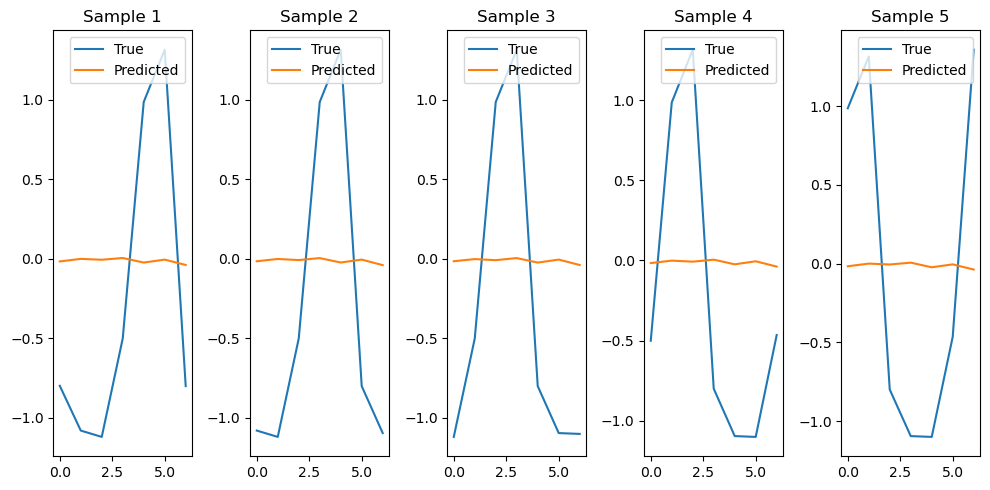

In [60]:
# Specify the target variable and covariates
target_column = "Gold_Price"
covariates = ['Natural_Gas_Price', 'Natural_Gas_Vol.', 'Crude_oil_Price', 'Crude_oil_Vol.', 
              'Copper_Price', 'Copper_Vol.', 'Gold_Price', 'Gold_Vol.']
torch.set_num_threads(7)

# Train and test the model
trained_model, test_loss = train_and_test_model(
    dataframe=df,
    target=target_column,
    covariates=covariates,
    seq_len=30,
    horizon=7,
    batch_size=64,
    epochs=10,
    learning_rate=0.001,
    channels=4,
    patch_sizes=[2, 3, 5],
    dynamic=True,
    num_nodes=1,
    mem_dim=4
)
